In [1]:
!pip install -q transformers faiss-cpu

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import faiss

from transformers import CLIPProcessor, CLIPModel

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Using device:", device)

Torch version: 2.5.1
CUDA available: False
Using device: cpu


In [4]:
import os

# ── Local paths ──────────────────────────────────────────────
CSV_PATH   = "/Users/deepakkatukuri/ML_final_project/food_recipe/data_raw/Food Ingredients and Recipe Dataset with Image Name Mapping.csv"
IMAGES_DIR = "/Users/deepakkatukuri/ML_final_project/images/data_raw/Food Images"

csv_files   = [CSV_PATH]
image_paths = [
    os.path.join(IMAGES_DIR, f)
    for f in os.listdir(IMAGES_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("CSV files:", csv_files)
print("Total images:", len(image_paths))

CSV files: ['/Users/deepakkatukuri/ML_final_project/food_recipe/data_raw/Food Ingredients and Recipe Dataset with Image Name Mapping.csv']
Total images: 13582


In [5]:
csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.columns)
df.head()

Shape: (13501, 6)
Index(['Unnamed: 0', 'Title', 'Ingredients', 'Instructions', 'Image_Name',
       'Cleaned_Ingredients'],
      dtype='object')


,Unnamed: 0,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients
0,0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","Pat chicken dry with paper towels, season all ...",miso-butter-roast-chicken-acorn-squash-panzanella,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher..."
1,1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...",Preheat oven to 400°F and line a rimmed baking...,crispy-salt-and-pepper-potatoes-dan-kluger,"['2 large egg whites', '1 pound new potatoes (..."
2,2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...",Place a rack in middle of oven; preheat to 400...,thanksgiving-mac-and-cheese-erick-williams,"['1 cup evaporated milk', '1 cup whole milk', ..."
3,3,Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in...",Preheat oven to 350°F with rack in middle. Gen...,italian-sausage-and-bread-stuffing-240559,"['1 (¾- to 1-pound) round Italian loaf, cut in..."
4,4,Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho...",Stir together brown sugar and hot water in a c...,newtons-law-apple-bourbon-cocktail,"['1 teaspoon dark brown sugar', '1 teaspoon ho..."


In [6]:
title_col = "Title"
ingredients_col = "Ingredients"
instructions_col = "Instructions"
image_col = "Image_Name"

print(df[[title_col, ingredients_col, instructions_col, image_col]].head())

                                               Title  \
0  Miso-Butter Roast Chicken With Acorn Squash Pa...   
1                    Crispy Salt and Pepper Potatoes   
2                        Thanksgiving Mac and Cheese   
3                 Italian Sausage and Bread Stuffing   
4                                       Newton's Law   

                                         Ingredients  \
0  ['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...   
1  ['2 large egg whites', '1 pound new potatoes (...   
2  ['1 cup evaporated milk', '1 cup whole milk', ...   
3  ['1 (¾- to 1-pound) round Italian loaf, cut in...   
4  ['1 teaspoon dark brown sugar', '1 teaspoon ho...   

                                        Instructions  \
0  Pat chicken dry with paper towels, season all ...   
1  Preheat oven to 400°F and line a rimmed baking...   
2  Place a rack in middle of oven; preheat to 400...   
3  Preheat oven to 350°F with rack in middle. Gen...   
4  Stir together brown sugar and hot water in 

In [7]:

def clean_text(x):
    if pd.isna(x):
        return ""
    return str(x).replace("\n", " ").replace("\r", " ").strip()

df["title_clean"] = df[title_col].apply(clean_text)
df["ingredients_clean"] = df[ingredients_col].apply(clean_text)
df["instructions_clean"] = df[instructions_col].apply(clean_text)

df["recipe_text"] = (
    df["title_clean"] +
    ". Ingredients: " + df["ingredients_clean"] +
    ". Instructions: " + df["instructions_clean"]
)

df = df.dropna(subset=[image_col]).reset_index(drop=True)

print(df.shape)
df.head()

(13501, 10)


,Unnamed: 0,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients,title_clean,ingredients_clean,instructions_clean,recipe_text
0,0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","Pat chicken dry with paper towels, season all ...",miso-butter-roast-chicken-acorn-squash-panzanella,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...",Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","Pat chicken dry with paper towels, season all ...",Miso-Butter Roast Chicken With Acorn Squash Pa...
1,1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...",Preheat oven to 400°F and line a rimmed baking...,crispy-salt-and-pepper-potatoes-dan-kluger,"['2 large egg whites', '1 pound new potatoes (...",Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...",Preheat oven to 400°F and line a rimmed baking...,Crispy Salt and Pepper Potatoes. Ingredients: ...
2,2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...",Place a rack in middle of oven; preheat to 400...,thanksgiving-mac-and-cheese-erick-williams,"['1 cup evaporated milk', '1 cup whole milk', ...",Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...",Place a rack in middle of oven; preheat to 400...,Thanksgiving Mac and Cheese. Ingredients: ['1 ...
3,3,Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in...",Preheat oven to 350°F with rack in middle. Gen...,italian-sausage-and-bread-stuffing-240559,"['1 (¾- to 1-pound) round Italian loaf, cut in...",Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in...",Preheat oven to 350°F with rack in middle. Gen...,Italian Sausage and Bread Stuffing. Ingredient...
4,4,Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho...",Stir together brown sugar and hot water in a c...,newtons-law-apple-bourbon-cocktail,"['1 teaspoon dark brown sugar', '1 teaspoon ho...",Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho...",Stir together brown sugar and hot water in a c...,Newton's Law. Ingredients: ['1 teaspoon dark b...


In [8]:
image_map = {}

for path in image_paths:
    name_without_ext = os.path.splitext(os.path.basename(path))[0]
    image_map[name_without_ext] = path

def find_image(image_name):
    image_name = str(image_name)
    image_name = os.path.splitext(image_name)[0]
    return image_map.get(image_name, None)

df["image_path"] = df[image_col].apply(find_image)

df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Matched image-recipe pairs:", df.shape)
df[["title_clean", "image_path"]].head()

Matched image-recipe pairs: (13471, 11)


,title_clean,image_path
0,Miso-Butter Roast Chicken With Acorn Squash Pa...,/Users/deepakkatukuri/ML_final_project/images/...
1,Crispy Salt and Pepper Potatoes,/Users/deepakkatukuri/ML_final_project/images/...
2,Thanksgiving Mac and Cheese,/Users/deepakkatukuri/ML_final_project/images/...
3,Italian Sausage and Bread Stuffing,/Users/deepakkatukuri/ML_final_project/images/...
4,Newton's Law,/Users/deepakkatukuri/ML_final_project/images/...


In [9]:
df = df.head(3000).reset_index(drop=True)

print("Final working dataset:", df.shape)

Final working dataset: (3000, 11)


Miso-Butter Roast Chicken With Acorn Squash Panzanella


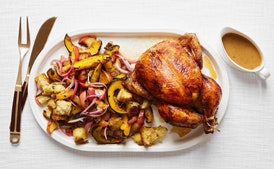

In [10]:
sample_id = 0

print(df.loc[sample_id, title_col])
Image.open(df.loc[sample_id, "image_path"])

In [11]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_model.eval()

print("CLIP model loaded successfully")

CLIP model loaded successfully


In [12]:
# Ingredient encoder: using CLIP text encoder (cell-13) — no separate model needed

In [13]:
# ============================================================
# 12. Image Embedding Function
# ============================================================

def get_image_embeddings(paths, batch_size=8):
    all_embeddings = []

    for i in tqdm(range(0, len(paths), batch_size)):
        batch_paths = paths[i:i + batch_size]
        images = []

        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
            except:
                img = Image.new("RGB", (224, 224), color="white")
            images.append(img)

        inputs = clip_processor(
            images=images,
            return_tensors="pt",
            padding=True
        )

        pixel_values = inputs["pixel_values"].to(device)

        with torch.no_grad():
            outputs = clip_model.vision_model(pixel_values=pixel_values)
            pooled_output = outputs.pooler_output
            emb = clip_model.visual_projection(pooled_output)
            emb = emb / emb.norm(dim=-1, keepdim=True)

        all_embeddings.append(emb.cpu().numpy())

    return np.vstack(all_embeddings)

In [14]:
# ============================================================
# 13. Text Embedding Function
# ============================================================

def get_clip_text_embeddings(texts, batch_size=8):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i + batch_size]

        inputs = clip_processor(
            text=batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        )

        input_ids = inputs["input_ids"].to(device)
        attention_mask = inputs["attention_mask"].to(device)

        with torch.no_grad():
            outputs = clip_model.text_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            pooled_output = outputs.pooler_output
            emb = clip_model.text_projection(pooled_output)
            emb = emb / emb.norm(dim=-1, keepdim=True)

        all_embeddings.append(emb.cpu().numpy())

    return np.vstack(all_embeddings)

In [15]:
# ============================================================
# 14. Generate Image Embeddings
# ============================================================

image_embeddings = get_image_embeddings(
    df["image_path"].tolist(),
    batch_size=8
)

print("Image embeddings:", image_embeddings.shape)

100%|██████████| 375/375 [00:35<00:00, 10.69it/s]

Image embeddings: (3000, 512)


In [16]:
# ============================================================
# 15. Generate Recipe Text Embeddings
# ============================================================

text_embeddings = get_clip_text_embeddings(
    df["recipe_text"].tolist(),
    batch_size=8
)

print("Text embeddings:", text_embeddings.shape)

100%|██████████| 375/375 [00:27<00:00, 13.76it/s]

Text embeddings: (3000, 512)


In [17]:
# ============================================================
# 16. Generate Ingredient Embeddings via CLIP Text Encoder
# ============================================================

ingredient_embeddings = get_clip_text_embeddings(
    df["ingredients_clean"].tolist(),
    batch_size=8
)

print("Ingredient embeddings:", ingredient_embeddings.shape)
# Expected: (3000, 512) — same space as text_embeddings, no padding needed

100%|██████████| 375/375 [00:26<00:00, 14.10it/s]

Ingredient embeddings: (3000, 512)


In [18]:
# Zero-padding removed: ingredient_embeddings already 512-dim from CLIP text encoder

In [19]:
# ============================================================
# 18. Ingredient-Aware Fusion  (α=0.9 — best from ablation)
# ============================================================

alpha = 0.9  # 90% full recipe text, 10% ingredient-only signal

recipe_embeddings = (
    alpha * text_embeddings +
    (1 - alpha) * ingredient_embeddings
)

recipe_embeddings = recipe_embeddings / np.linalg.norm(
    recipe_embeddings,
    axis=1,
    keepdims=True
)

print("Final recipe embeddings:", recipe_embeddings.shape)

Final recipe embeddings: (3000, 512)


In [20]:
# ============================================================
# 19. Build FAISS Index
# ============================================================

dim = recipe_embeddings.shape[1]

recipe_index = faiss.IndexFlatIP(dim)
recipe_index.add(recipe_embeddings.astype("float32"))

image_index = faiss.IndexFlatIP(dim)
image_index.add(image_embeddings.astype("float32"))

print("FAISS indexes created")
print("Recipe index size:", recipe_index.ntotal)
print("Image index size:", image_index.ntotal)

FAISS indexes created
Recipe index size: 3000
Image index size: 3000


In [21]:
# ============================================================
# 20. Image to Recipe Search
# ============================================================

def search_recipe_by_image(row_id, top_k=5):
    query_embedding = image_embeddings[row_id:row_id + 1].astype("float32")

    scores, indices = recipe_index.search(query_embedding, top_k)

    results = df.iloc[indices[0]][[
        title_col,
        ingredients_col,
        instructions_col,
        "image_path"
    ]].copy()

    results["similarity_score"] = scores[0]

    return results

Query Image Title:
Hot Pimento Cheese Dip


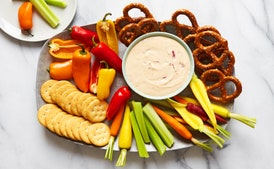

In [22]:
# Test Image to Recipe Search

row_id = 10

print("Query Image Title:")
print(df.loc[row_id, title_col])

Image.open(df.loc[row_id, "image_path"])

In [23]:
search_recipe_by_image(row_id, top_k=5)

,Title,Ingredients,Instructions,image_path,similarity_score
517,Smoky Carrot Dip,"['½ cup skin-on almonds', '2 lb. carrots, trim...",Preheat oven to 350°F. Toast almonds on a rimm...,/Users/deepakkatukuri/ML_final_project/images/...,0.324869
10,Hot Pimento Cheese Dip,['1 (7 oz./200 g) can chipotle in adobo sauce'...,Put the chipotle peppers and adobo sauce in a ...,/Users/deepakkatukuri/ML_final_project/images/...,0.319609
2252,Creamy Pinto Bean Dip,"['1 tablespoon olive oil', '1/3 cup chopped re...",Heat oil in a large skillet over medium. Add o...,/Users/deepakkatukuri/ML_final_project/images/...,0.316036
1138,Easy Canned Chickpea Hummus,"['2 (15-oz.) cans chickpeas, drained, rinsed',...",Place chickpeas in a medium pot and cover with...,/Users/deepakkatukuri/ML_final_project/images/...,0.314069
1492,Crudités with Chile-Lime Salt,"['1 lime', '2 tablespoons flaky sea salt', '1/...",Finely grate lime zest into a small bowl. Stir...,/Users/deepakkatukuri/ML_final_project/images/...,0.310692


In [24]:
# ============================================================
# 21. Recipe to Image Search
# ============================================================

def search_image_by_recipe(row_id, top_k=5):
    query_embedding = recipe_embeddings[row_id:row_id + 1].astype("float32")

    scores, indices = image_index.search(query_embedding, top_k)

    results = df.iloc[indices[0]][[
        title_col,
        "image_path"
    ]].copy()

    results["similarity_score"] = scores[0]

    return results

In [25]:
# Test Recipe to Image Search

row_id = 10

print("Query Recipe:")
print(df.loc[row_id, title_col])

search_image_by_recipe(row_id, top_k=5)

Query Recipe:
Hot Pimento Cheese Dip


,Title,image_path,similarity_score
2261,Five-Cheese Pimento Cheese,/Users/deepakkatukuri/ML_final_project/images/...,0.370845
1629,Sweet Potato–Tahini Dip with Za'atar,/Users/deepakkatukuri/ML_final_project/images/...,0.353167
2299,Instant-Pot Vegan Cauliflower Queso,/Users/deepakkatukuri/ML_final_project/images/...,0.340299
455,Smoked Salmon Tartare,/Users/deepakkatukuri/ML_final_project/images/...,0.337449
2252,Creamy Pinto Bean Dip,/Users/deepakkatukuri/ML_final_project/images/...,0.328867


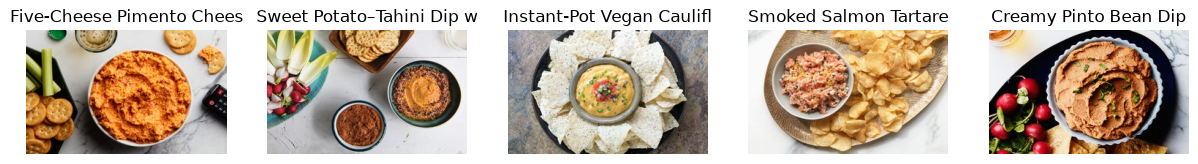

In [26]:
# ============================================================
# 22. Display Top Retrieved Images
# ============================================================

def show_retrieved_images(row_id, top_k=5):
    results = search_image_by_recipe(row_id, top_k)

    plt.figure(figsize=(15, 4))

    for i, (_, row) in enumerate(results.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")

        plt.subplot(1, top_k, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(row[title_col][:25])

    plt.show()

show_retrieved_images(row_id=10, top_k=5)

In [27]:
# ============================================================
# 23. Free CLIP model from RAM — embeddings already computed
# ============================================================
import gc

del clip_model
del clip_processor
gc.collect()

print("CLIP model freed from memory")

CLIP model freed from memory


In [ ]:
# ============================================================
# 24. Recall@K and Median Rank Evaluation
# ============================================================

def recall_at_k(query_embeddings, index, k):
    scores, indices = index.search(query_embeddings.astype("float32"), k)
    correct = sum(1 for i in range(len(query_embeddings)) if i in indices[i])
    return correct / len(query_embeddings)


def median_rank(query_embs, db_embs, chunk_size=300):
    # Chunked matmul — avoids large peak RAM on CPU
    n = len(query_embs)
    ranks = []
    db = db_embs.astype("float32")
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        chunk = query_embs[start:end].astype("float32")
        sim = chunk @ db.T                                  # (chunk, N)
        diag = sim[np.arange(end - start), np.arange(start, end)]
        chunk_ranks = (sim > diag.reshape(-1, 1)).sum(axis=1) + 1
        ranks.extend(chunk_ranks.tolist())
        del sim, chunk
        gc.collect()
    return float(np.median(ranks))

: 

In [ ]:
results = []

im2r_medR = median_rank(image_embeddings, recipe_embeddings)
r2im_medR = median_rank(recipe_embeddings, image_embeddings)

for k in [1, 5, 10]:
    image_to_recipe = recall_at_k(image_embeddings, recipe_index, k)
    recipe_to_image = recall_at_k(recipe_embeddings, image_index, k)
    results.append({
        "K": k,
        "Image_to_Recipe_Recall": round(image_to_recipe, 4),
        "Recipe_to_Image_Recall": round(recipe_to_image, 4),
    })

results_df = pd.DataFrame(results)
results_df["Image_to_Recipe_medR"] = im2r_medR
results_df["Recipe_to_Image_medR"] = r2im_medR

print(f"Median Rank  Im→Recipe: {im2r_medR:.1f}   Recipe→Im: {r2im_medR:.1f}")
results_df

/var/folders/v7/7g0r7rns0v93ywzd_wf35z5h0000gn/T/ipykernel_80156/2854121660.py:19: RuntimeWarning: divide by zero encountered in matmul
  sim = chunk @ db.T                                  # (chunk, N)
/var/folders/v7/7g0r7rns0v93ywzd_wf35z5h0000gn/T/ipykernel_80156/2854121660.py:19: RuntimeWarning: overflow encountered in matmul
  sim = chunk @ db.T                                  # (chunk, N)
/var/folders/v7/7g0r7rns0v93ywzd_wf35z5h0000gn/T/ipykernel_80156/2854121660.py:19: RuntimeWarning: invalid value encountered in matmul
  sim = chunk @ db.T                                  # (chunk, N)


In [ ]:
import os

OUTPUT_DIR = "/Users/deepakkatukuri/ML_final_project/runs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results_df.to_csv(f"{OUTPUT_DIR}/retrieval_results.csv", index=False)
print("Saved:", f"{OUTPUT_DIR}/retrieval_results.csv")

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(results_df["K"], results_df["Image_to_Recipe_Recall"], marker="o", label="Image to Recipe")
plt.plot(results_df["K"], results_df["Recipe_to_Image_Recall"], marker="o", label="Recipe to Image")

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Food Image-Recipe Retrieval Performance")
plt.legend()
plt.grid(True)

plt.savefig(f"{OUTPUT_DIR}/recall_results.pdf", bbox_inches="tight")
plt.show()
print("Saved:", f"{OUTPUT_DIR}/recall_results.pdf")

In [ ]:
# ============================================================
# 26. Fusion Weight Comparison
# ============================================================

fusion_results = []

for alpha in [0.3, 0.5, 0.7, 0.9]:
    fused_embeddings = (
        alpha * text_embeddings +
        (1 - alpha) * ingredient_embeddings
    )

    fused_embeddings = fused_embeddings / np.linalg.norm(
        fused_embeddings,
        axis=1,
        keepdims=True
    )

    temp_index = faiss.IndexFlatIP(fused_embeddings.shape[1])
    temp_index.add(fused_embeddings.astype("float32"))

    r1 = recall_at_k(image_embeddings, temp_index, 1)
    r5 = recall_at_k(image_embeddings, temp_index, 5)
    r10 = recall_at_k(image_embeddings, temp_index, 10)

    fusion_results.append({
        "Text_Weight_Alpha": alpha,
        "Recall@1": r1,
        "Recall@5": r5,
        "Recall@10": r10
    })

fusion_df = pd.DataFrame(fusion_results)

fusion_df

In [ ]:
fusion_df.to_csv(f"{OUTPUT_DIR}/fusion_comparison.csv", index=False)
print("Saved:", f"{OUTPUT_DIR}/fusion_comparison.csv")

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(fusion_df["Text_Weight_Alpha"], fusion_df["Recall@1"], marker="o", label="Recall@1")
plt.plot(fusion_df["Text_Weight_Alpha"], fusion_df["Recall@5"], marker="o", label="Recall@5")
plt.plot(fusion_df["Text_Weight_Alpha"], fusion_df["Recall@10"], marker="o", label="Recall@10")

plt.xlabel("Text Fusion Weight Alpha")
plt.ylabel("Recall")
plt.title("Effect of Ingredient-Aware Fusion Weight")
plt.legend()
plt.grid(True)

plt.savefig(f"{OUTPUT_DIR}/fusion_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved:", f"{OUTPUT_DIR}/fusion_comparison.pdf")

In [ ]:
np.save(f"{OUTPUT_DIR}/image_embeddings.npy", image_embeddings)
np.save(f"{OUTPUT_DIR}/text_embeddings.npy", text_embeddings)
np.save(f"{OUTPUT_DIR}/recipe_embeddings.npy", recipe_embeddings)

print("Embeddings saved to:", OUTPUT_DIR)

In [ ]:
# ============================================================
# 30. Final Summary
# ============================================================

print("Project completed successfully")
print("Total samples used:", len(df))
print("Main output files:")
print("1. retrieval_results.csv")
print("2. fusion_comparison.csv")
print("3. recall_results.pdf")
print("4. fusion_comparison.pdf")
print("5. image_embeddings.npy")
print("6. recipe_embeddings.npy")

Project completed successfully
Total samples used: 3000
Main output files:
1. retrieval_results.csv
2. fusion_comparison.csv
3. recall_results.pdf
4. fusion_comparison.pdf
5. image_embeddings.npy
6. recipe_embeddings.npy


In [ ]:
# ============================================================
# INTERACTIVE DEMO — paste any food image URL below
# ============================================================
import requests

url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Spaghetti_bolognese_%28hozinja%29.jpg/800px-Spaghetti_bolognese_%28hozinja%29.jpg"

# Fetch and display query image
response = requests.get(url, stream=True, timeout=10)
query_img = Image.open(response.raw).convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(query_img)
plt.axis("off")
plt.title("Query Image")
plt.show()

# Encode query image with CLIP
inputs = clip_processor(images=query_img, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)

with torch.no_grad():
    outputs = clip_model.vision_model(pixel_values=pixel_values)
    pooled = outputs.pooler_output
    query_emb = clip_model.visual_projection(pooled)
    query_emb = query_emb / query_emb.norm(dim=-1, keepdim=True)

query_np = query_emb.cpu().numpy().astype("float32")

# Search top-5 recipes
scores, indices = recipe_index.search(query_np, 5)

print("\nTop-5 Retrieved Recipes:\n" + "=" * 50)
for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), 1):
    print(f"\n#{rank}  {df.loc[idx, title_col]}  (score: {score:.3f})")
    print(f"    {str(df.loc[idx, ingredients_col])[:200]}...")